<a id="inicio"></a>
    # AED 08 · Optimización no lineal, riesgo y aprendizaje secuencial

    **Profundización docente / adaptación a postgrado; no exigencia adicional del programa** · Colección docente · Edición 2026-10-08.

    Ejecute todas las celdas en orden con el entorno documentado en `../reproducibilidad/README.md`.
    Los controles necesitan kernel activo; las salidas guardadas permiten lectura. Los datos son
    casos docentes locales; las simulaciones y parámetros económicos se identifican como supuestos.
    Consulte la [guía maestra](../guia_maestra_aed.html), el
    [manual científico](../material_propio/AED_manual_cientifico.pdf) y la
    [matriz curricular](../COBERTURA.md). Los ejercicios son formativos.

### Antes de ejecutar

Profundización · 90–120 min orientativos.

**Objetivo:** Analizar sensibilidad, colas y aprendizaje secuencial sin extrapolar garantías.

**Preparación:** Álgebra, probabilidad, optimización y lectura de funciones en Python.

**Ejemplo de referencia:** Comparar media-varianza, riesgo de cola y políticas UCB sobre múltiples semillas.

**Práctica:** Modificar aversión al riesgo o mecanismo de recompensa y evaluar estabilidad de la política.

**Criterio de logro:** Defender supuestos, criterio de riesgo, comparación independiente y límite de transferencia.

[Guía y secuencia](../guia_maestra_aed.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/AED_manual_cientifico.html#sec-profundizacion)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
RAIZ=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'_transversal/datos').is_dir())
sys.path.insert(0,str(RAIZ/'04_Analitica_Estrategica_Datos/reproducibilidad'))
from aed_recursos import (casapeumo, indicadores, boldonet, plan_produccion,
                         decision, solar, resumen_solar, pregunta, DATOS, SEMILLA)
plt.rcParams.update({'figure.figsize':(8,3.5),'axes.spines.top':False,'axes.spines.right':False})

<a id="no-lineal"></a>
## 1. Precio con demanda y dominio

Demanda docente $q(p)=\max(0,120-2p)$; costo unitario 15 UM y precio factible [15,60].
La contribución es $\pi(p)=(p-15)(120-2p)$ dentro del dominio: una parábola cóncava.
La derivada $150-4p=0$ entrega $p^*=37.5$. Comparamos solución analítica, malla y solver.
Fuera de este ejemplo, una función no convexa puede tener óptimos locales; iniciar en varios
puntos es diagnóstico, no demostración de optimalidad global. La curva de demanda es supuesta,
no estimada causalmente de observaciones de precio.

In [2]:
from scipy.optimize import minimize_scalar,minimize
def contribucion(p):return (p-15)*max(0,120-2*p)
opt=minimize_scalar(lambda p:-contribucion(p),bounds=(15,60),method='bounded')
assert opt.success and np.isclose(opt.x,37.5,atol=1e-4)
grid=np.linspace(15,60,1000)
assert -opt.fun>=max(map(contribucion,grid))-1e-6
@widgets.interact(precio=widgets.FloatSlider(value=37.5,min=15,max=60,step=.5))
def explorar_precio(precio=37.5):
    fig,ax=plt.subplots();ax.plot(grid,[contribucion(p) for p in grid]);ax.scatter([precio],[contribucion(precio)],color='#bd8841');ax.set(xlabel='Precio UM',ylabel='Contribución UM');plt.show();plt.close(fig)

interactive(children=(FloatSlider(value=37.5, description='precio', max=60.0, min=15.0, step=0.5), Output()), …

<a id="cartera"></a>
## 2. Media-varianza como problema de asignación

Con pesos $w\ge0$, $1^Tw=1$, minimizamos $\frac{\lambda}{2}w^T\Sigma w-\mu^Tw$.
Medias y covarianzas son parámetros sintéticos, no recomendaciones de inversión. Matriz positiva
semidefinida y restricciones convexas hacen convexo el problema. La incertidumbre de parámetros,
colas y costos puede dominar el resultado; analice sensibilidad. Penalizar varianza trata ganancias
y pérdidas simétricamente y no representa todas las preferencias de riesgo.

In [3]:
mu=np.array([.05,.08,.11]);S=np.array([[.01,.002,.001],[.002,.0225,.006],[.001,.006,.04]])
assert np.linalg.eigvalsh(S).min()>0
@widgets.interact(aversion=widgets.FloatSlider(value=4,min=.5,max=12,step=.5))
def cartera(aversion=4):
    r=minimize(lambda w:aversion/2*w@S@w-mu@w,np.ones(3)/3,
      jac=lambda w:aversion*S@w-mu,method='SLSQP',bounds=[(0,1)]*3,
      constraints={'type':'eq','fun':lambda w:w.sum()-1,'jac':lambda w:np.ones(3)},options={'ftol':1e-12})
    assert r.success and np.isclose(r.x.sum(),1) and min(r.x)>=-1e-8
    display(pd.Series({'pesos':r.x.round(4).tolist(),'retorno_supuesto':mu@r.x,'desviacion':np.sqrt(r.x@S@r.x)}))

interactive(children=(FloatSlider(value=4.0, description='aversion', max=12.0, min=0.5, step=0.5), Output()), …

<a id="colas"></a>
## 3. Riesgo de cola y robustez

Defina pérdida $L=-VAN$. VaR al 95% es su percentil 95; para distribución continua, CVaR es la
media condicional de la cola superior. En muestras/distribuciones discretas se necesita ponderar
la masa en el umbral para obtener exactamente el 5% de cola. Aquí promediamos los 500 peores
de 10000 escenarios: una definición empírica transparente. Cambiar parámetros o modelo de shocks
es sensibilidad estructural, distinta de aumentar N.

In [4]:
s=solar(n=10000);perdida=-s.VAN.to_numpy();q=np.quantile(perdida,.95)
k=int(.05*len(perdida));cvar=np.sort(perdida)[-k:].mean()
assert cvar>=q
display(pd.Series({'VaR_95_kUM':q,'CVaR_95_empirico_kUM':cvar,'peor_VAN':s.VAN.min()}))
sens=pd.DataFrame([{'rho_latente':rho,**resumen_solar(solar(rho=rho))} for rho in [-.6,0,.6]])
display(sens)

VaR_95_kUM              100.608507
CVaR_95_empirico_kUM    121.853213
peor_VAN               -185.607062
dtype: float64

,rho_latente,VAN_medio,P_perdida,P05,P95,SE_media,SE_probabilidad
0,-0.6,10.271255,0.4613,-80.877525,119.383422,0.611420,0.004985
1,0.0,15.703601,0.4786,-113.371136,181.709240,0.907214,0.004995
2,0.6,20.869518,0.4803,-134.164275,234.263466,1.133217,0.004996


<a id="bandido"></a>
## 4. Explorar y explotar: bandido no es un MDP completo

Un bandido tiene acciones y recompensas sin dinámica de estado explícita. UCB selecciona la
acción con media estimada más un bono de exploración; un MDP incorpora transición y retorno
descontado. En aplicaciones empresariales, asignar acciones exploratorias puede afectar clientes:
restrinja elegibilidad, costos, exposición y reglas de parada antes de experimentar.

Simulamos tres acciones con probabilidad de éxito [0.25,0.35,0.45]. Medimos arrepentimiento
esperado acumulado usando las medias conocidas del simulador; en datos reales esas medias no se
conocen. Una trayectoria favorable no demuestra superioridad: compare múltiples semillas.

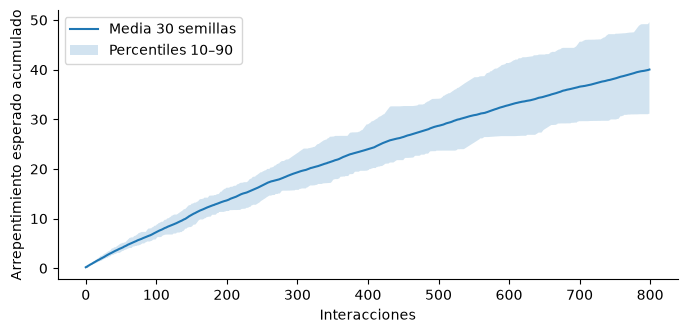

In [5]:
def bandido(semilla,T=800):
    rng=np.random.default_rng(semilla);medias=np.array([.25,.35,.45]);conteo=np.zeros(3);suma=np.zeros(3);regret=[]
    for t in range(T):
        a=t if t<3 else int(np.argmax(suma/conteo+np.sqrt(2*np.log(t+1)/conteo)))
        premio=rng.binomial(1,medias[a]);conteo[a]+=1;suma[a]+=premio
        regret.append(medias.max()-medias[a])
    return np.cumsum(regret),conteo
runs=np.array([bandido(seed)[0] for seed in range(30)])
assert np.all(np.diff(runs,axis=1)>=-1e-10)
fig,ax=plt.subplots();ax.plot(runs.mean(axis=0),label='Media 30 semillas');ax.fill_between(np.arange(800),np.quantile(runs,.1,axis=0),np.quantile(runs,.9,axis=0),alpha=.2,label='Percentiles 10–90');ax.set(xlabel='Interacciones',ylabel='Arrepentimiento esperado acumulado');ax.legend();plt.show();plt.close(fig)

<a id="mdp"></a>
## 5. Ecuación de Bellman y política

Para estados y acciones finitos, $Q^*(s,a)=E[r+\gamma\max_{a'}Q^*(s',a')\mid s,a]$.
Con $0\le\gamma<1$ y recompensas acotadas, el operador de Bellman es una contracción.
El ejemplo de dos estados resuelve planificación con transiciones **conocidas**, no aprende una
política a partir de datos empresariales. Q-learning reemplazaría esa esperanza por actualizaciones
muestrales y requeriría condiciones de exploración y pasos; una simulación no certifica despliegue.

**Ejercicio.** Cambie el costo de la intervención y observe la política. Explique qué cambia si las
transiciones están sesgadas o si no se observan variables de confusión. Solución: la política es
óptima respecto del modelo; un modelo incorrecto puede recomendar una acción perjudicial.

In [6]:
P=np.array([[[.85,.15],[.95,.05]],[[.25,.75],[.65,.35]]]) # estado, acción, siguiente estado
R=np.array([[5.,3.],[-4.,-2.]])
gamma=.9;V=np.zeros(2)
assert np.allclose(P.sum(axis=2),1)
for _ in range(1000):
    Q=R+gamma*np.einsum('sak,k->sa',P,V);nuevo=Q.max(axis=1)
    if np.max(abs(nuevo-V))<1e-10: V=nuevo;break
    V=nuevo
Q=R+gamma*np.einsum('sak,k->sa',P,V)
assert np.max(abs(Q.max(axis=1)-V))<1e-8
display(pd.DataFrame({'estado':['estable','en_riesgo'],'valor':V,'accion_optima':Q.argmax(axis=1)}))

,estado,valor,accion_optima
0,estable,38.475610,0
1,en_riesgo,29.939024,1


<a id="autoevaluacion"></a>
## Autoevaluación
Seleccione y compruebe su respuesta.

In [7]:
auto_08=pregunta('¿Qué garantiza el óptimo calculado por un modelo de decisión?', ['El mejor resultado real sin condiciones', 'El mejor resultado según el modelo, dominio y supuestos verificados', 'Que los datos de entrada no tienen sesgo'], 1, 'La corrección del solver no valida por sí misma el modelo ni las consecuencias de implementarlo.')